In [1]:
import numpy as np
import pandas as pd
import statistics
import math as m

from sklearnex import patch_sklearn
patch_sklearn()

from modAL.models import ActiveLearner
from modAL.uncertainty import uncertainty_sampling

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from kmodes.kmodes import KModes
from sklearn import preprocessing

import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
data = pd.read_csv('dataset.csv')
data = data.drop(columns = ['Unnamed: 0','alpha_risk'])
data

,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_9,Q_10,Q_11,Q_12,Q_13,Q_14,Q_15,risk_label,gender,age,sex_orient,immigrant
0,0,1,0,1,0,0,1,1,1,1,1,1,1,0,1,risky,1,4,0,0
1,0,0,0,1,1,1,0,1,0,0,1,1,0,1,0,risky,0,2,0,0
2,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,safe,1,1,0,0
3,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,safe,0,0,0,1
4,0,1,0,1,1,1,0,1,1,1,1,0,0,0,1,risky,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0,1,1,1,1,0,0,1,1,1,0,1,1,1,risky,0,3,0,0
996,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,safe,0,2,0,0
997,1,1,0,1,1,0,0,0,1,1,0,1,0,0,1,safe,0,3,0,0
998,0,0,1,1,0,0,0,1,0,0,0,1,1,1,0,risky,0,4,1,1


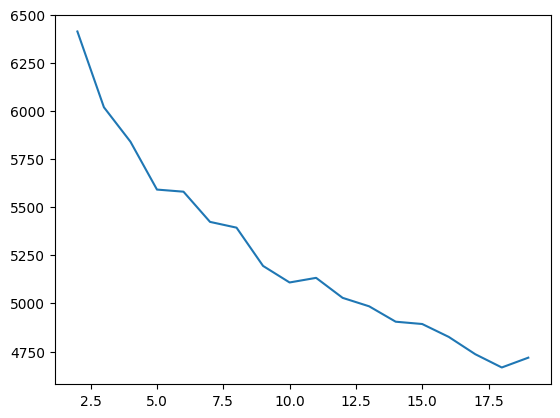

In [3]:
cost = []
K = range(2,20)
for k in range(2,20):
    kmode = KModes(n_clusters=k, init = "Huang", n_init = 5,random_state=100)
    kmode.fit_predict(data)
    cost.append(kmode.cost_)

plt.plot(K,cost) # Con 18 clusters

In [4]:
km = KModes(n_clusters=18, init = "Huang", n_init = 5)
clusters = km.fit_predict(data)
data['cluster'] = clusters
data

,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_9,Q_10,...,Q_12,Q_13,Q_14,Q_15,risk_label,gender,age,sex_orient,immigrant,cluster
0,0,1,0,1,0,0,1,1,1,1,...,1,1,0,1,risky,1,4,0,0,3
1,0,0,0,1,1,1,0,1,0,0,...,1,0,1,0,risky,0,2,0,0,17
2,1,1,1,0,0,1,0,1,0,0,...,0,0,0,0,safe,1,1,0,0,6
3,0,1,0,0,0,1,0,1,0,0,...,0,0,0,0,safe,0,0,0,1,12
4,0,1,0,1,1,1,0,1,1,1,...,0,0,0,1,risky,1,1,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0,1,1,1,1,0,0,1,1,...,0,1,1,1,risky,0,3,0,0,2
996,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,safe,0,2,0,0,16
997,1,1,0,1,1,0,0,0,1,1,...,1,0,0,1,safe,0,3,0,0,4
998,0,0,1,1,0,0,0,1,0,0,...,1,1,1,0,risky,0,4,1,1,9


In [5]:
data['cluster'].unique()

array([ 3, 17,  6, 12, 15,  8, 10,  5, 16, 14,  1,  9, 11,  2,  0, 13,  4,
        7], dtype=uint16)

In [6]:
def conmutar(x):
    if x ==  'safe':
        return 'risky'
    else:
        return 'safe'

def actualizar_dif(dif,listscore,listres):
    zeros = 0
    ones = 0
    for score, res in zip(listscore,listres):
        if res == 0:
            zeros +=1
        else:
            ones +=1

    #Probar kappa-> Descartado porque se hace en una sola tarea y para eso no vale
    """
    p0 = (zeros/(zeros+ones))**2+(ones/(zeros+ones))**2

    pe = 1*len(listscore)*(len(listscore)-1)*((zeros/(zeros+ones))**2+(ones/(zeros+ones))**2 - len(listscore))

    kappa = (p0 - pe)/(1 - pe)
    kappa = 0.5 - kappa
    """
    if zeros == 0 and ones == 0:
        entropy = 0  
    elif zeros == 0:
        entropy = - (m.log(ones/(ones+zeros))*(ones/(ones+zeros)))
    elif ones == 0:
        entropy = - (m.log(zeros/(ones+zeros))*(zeros/(ones+zeros)))
    else:
        entropy = - ((m.log(ones/(ones+zeros))*(ones/(ones+zeros)))+ (m.log(zeros/(ones+zeros))*(zeros/(ones+zeros))))
    # Que pasa si están la mayoría mal
    entropy = (entropy - 0.5) * 2
    # print(f"Proporción: {zeros}|0 + {ones}|1 = {entropy}")
    new_dif = dif + (entropy * rate_dif) 
    return new_dif

def actualizar_score(lista_res,lista_scores,lista_probs,dis):
    new_scores = []
    for prob,res,score in zip(lista_probs,lista_res,lista_scores):
        if prob == 1:
            item = score
        else:
            item = score + ((res-prob)/(dis*prob*(1-prob)))
        new_scores.append(item)

    return new_scores

def actualizar_dis(lista_res,dis,lista_probs,dif,lista_scores):
    new_dis = dis
    suma = 0
    for prob,res,score in zip(lista_probs,lista_res,lista_scores):
        suma = suma + (res-prob)*(score-dif)
    new_dis = dis + (suma*rate)/len(lista_scores)
    
    return new_dis

def cal_probs(listscores,dis,dif):
    
    listprobs = []
    for score in listscores:
        prob = (m.exp(dis*(score-dif))/(1 + m.exp(dis*(score-dif))))
        listprobs.append(prob)

    return listprobs

def rand_imputar(listscores,res,index):
    
    cluster = data["cluster"].loc[index]
    dis = list_dis[cluster]
    dif = list_dif[cluster]
    
    listprob = cal_probs(listscores,dis,dif)

    lista = [x / sum(listprob) for x in listprob]
    decisiones = []
    aciertos = []
    votacion = []

    for e in listprob:
        dice = np.random.random()
        if dice > (e):
            decisiones.append(conmutar(res))
            aciertos.append(0)
        else:
            decisiones.append(res)
            aciertos.append(1)

    for i,e in enumerate(lista):
        for j in range(int(round(e*100))):
            votacion.append(decisiones[i])
            
    fin = statistics.mode(votacion)

    listscores = actualizar_score(aciertos,listscores,listprob,dis)

    new_dis = actualizar_dis(aciertos,dis,listprob,dif,listscores)

    new_dif = actualizar_dif(dif,listscores,aciertos)

    list_dif[cluster] = new_dif

    list_dis[cluster] = new_dis

    return decisiones,str(fin)

In [7]:
con_stories = []

seeds = [10,20,30,40,50]


for s in seeds:
    np.random.seed(s)

    control_anot = [5]
    
    rate = 0.01
    rate_dif = 0.1
    list_dif = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
    list_dis = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

    X = data.drop(columns = ['risk_label','cluster']).to_numpy()
    Y = data['risk_label'].to_numpy()
    
    X_train, X_pool, Y_train, Y_pool = train_test_split(X, Y,test_size=0.98,random_state=s)
    
    X_pool, X_test, Y_pool, Y_test = train_test_split(X_pool, Y_pool,test_size=0.2,random_state=s)
    
    learner = ActiveLearner(
        estimator=RandomForestClassifier(random_state=s),
        query_strategy=uncertainty_sampling,
        X_training=X_train, y_training=Y_train)
    
    unqueried_score = learner.score(X_test, Y_test)
    
    performance_history = [unqueried_score]
    
    n_queries = min(400,X_pool.shape[0])
    
    for index in range(n_queries):
    
        uncertainty = learner.predict_proba(X_pool)
        max_uncertainty = np.max(uncertainty, axis=1)
    
        max_uncertainty = np.min(max_uncertainty)
        
        if max_uncertainty > 0.6:
            break
        
        query_index, query_instance = learner.query(X_pool)
    
        # Teach our ActiveLearner model the record it has requested.
        x,y = X_pool[query_index].reshape(1, -1), Y_pool[query_index].reshape(1, )
        y = [rand_imputar(control_anot,y[0],query_index[0])[1]]
        learner.teach(X=x, y=y)
    
        # Remove the queried instance from the unlabeled pool.
        X_pool, Y_pool = np.delete(X_pool, query_index, axis=0), np.delete(Y_pool, query_index)
    
        # Calculate and report our model's accuracy.
        model_accuracy = learner.score(X_test, Y_test)
    
        # Save our model's performance for plotting.
        performance_history.append(model_accuracy)

    con_stories.append(performance_history)

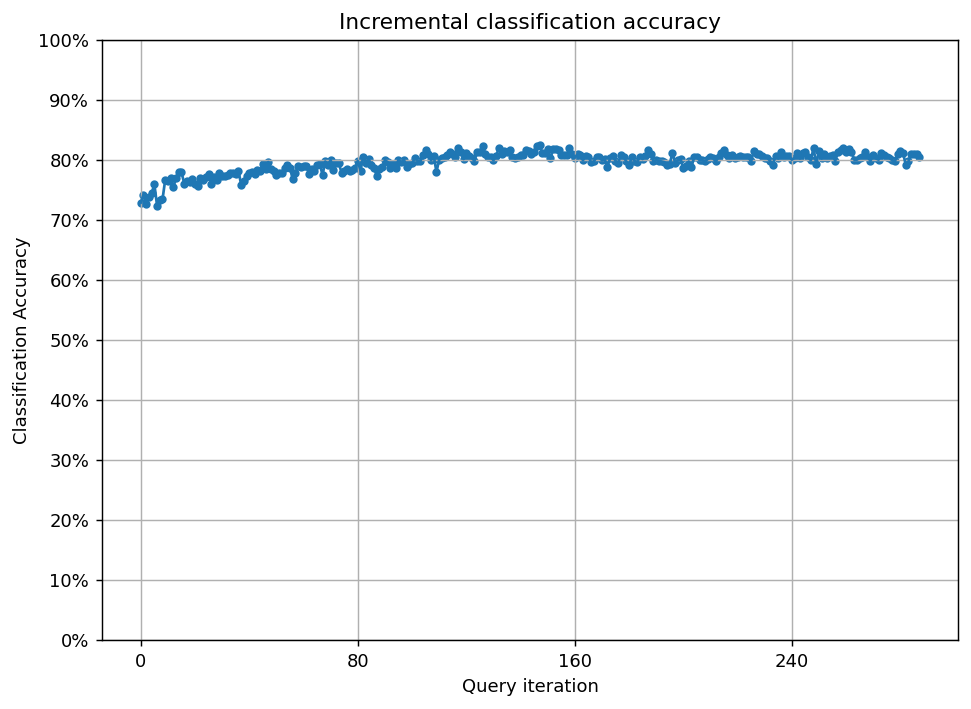

In [8]:
min_len = min(len(s) for s in con_stories)
con_stories = [s[:min_len] for s in con_stories]
med_stories_con = [np.mean(vals) for vals in zip(*con_stories)]

# Plot our performance over time.
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories_con)
ax.scatter(range(len(med_stories_con)), med_stories_con, s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')

plt.show()

In [9]:
prof_stories = []

seeds = [10,20,30,40,50]


for s in seeds:
    np.random.seed(s)

    prof_anot = np.random.normal(loc=1.5, scale=0.5, size=(5,)).tolist()
    
    rate = 0.01
    rate_dif = 0.1
    list_dif = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
    list_dis = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

    X = data.drop(columns = ['risk_label','cluster']).to_numpy()
    Y = data['risk_label'].to_numpy()
    
    X_train, X_pool, Y_train, Y_pool = train_test_split(X, Y,test_size=0.98,random_state=s)
    
    X_pool, X_test, Y_pool, Y_test = train_test_split(X_pool, Y_pool,test_size=0.2,random_state=s)
    
    learner = ActiveLearner(
        estimator=RandomForestClassifier(random_state=s),
        query_strategy=uncertainty_sampling,
        X_training=X_train, y_training=Y_train)
    
    unqueried_score = learner.score(X_test, Y_test)
    
    performance_history = [unqueried_score]

    n_queries = min(400,X_pool.shape[0])
    
    for index in range(n_queries):
    
        uncertainty = learner.predict_proba(X_pool)
        max_uncertainty = np.max(uncertainty, axis=1)
    
        max_uncertainty = np.min(max_uncertainty)
        
        if max_uncertainty > 0.6:
            break
        
        query_index, query_instance = learner.query(X_pool)
    
        # Teach our ActiveLearner model the record it has requested.
        x,y = X_pool[query_index].reshape(1, -1), Y_pool[query_index].reshape(1, )
        y = [rand_imputar(prof_anot,y[0],query_index[0])[1]]
        learner.teach(X=x, y=y)
    
        # Remove the queried instance from the unlabeled pool.
        X_pool, Y_pool = np.delete(X_pool, query_index, axis=0), np.delete(Y_pool, query_index)
    
        # Calculate and report our model's accuracy.
        model_accuracy = learner.score(X_test, Y_test)
    
        # Save our model's performance for plotting.
        performance_history.append(model_accuracy)

    prof_stories.append(performance_history)

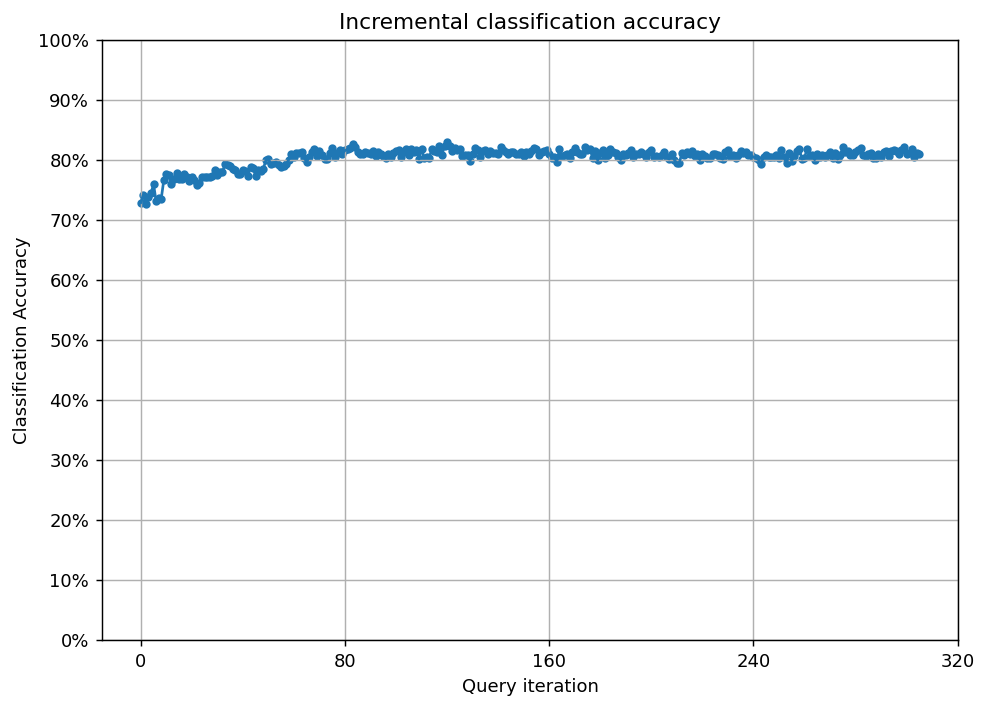

In [10]:
min_len = min(len(s) for s in prof_stories)
prof_stories = [s[:min_len] for s in prof_stories]
med_stories_prof = [np.mean(vals) for vals in zip(*prof_stories)]

# Plot our performance over time.
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories_prof)
ax.scatter(range(len(med_stories_prof)), med_stories_prof, s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')

plt.show()

In [11]:
crw_stories = []

seeds = [10,20,30,40,50]


for s in seeds:
    np.random.seed(s)

    crowd_anot = np.random.normal(loc=0, scale=1, size=(50,)).tolist()
    
    rate = 0.01
    rate_dif = 0.1
    list_dif = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
    list_dis = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

    X = data.drop(columns = ['risk_label','cluster']).to_numpy()
    Y = data['risk_label'].to_numpy()
    
    X_train, X_pool, Y_train, Y_pool = train_test_split(X, Y,test_size=0.98,random_state=s)
    
    X_pool, X_test, Y_pool, Y_test = train_test_split(X_pool, Y_pool,test_size=0.2,random_state=s)
    
    learner = ActiveLearner(
        estimator=RandomForestClassifier(random_state=s),
        query_strategy=uncertainty_sampling,
        X_training=X_train, y_training=Y_train)
    
    unqueried_score = learner.score(X_test, Y_test)
    
    performance_history = [unqueried_score]

    n_queries = min(400,X_pool.shape[0])
    
    for index in range(n_queries):
    
        uncertainty = learner.predict_proba(X_pool)
        max_uncertainty = np.max(uncertainty, axis=1)
    
        max_uncertainty = np.min(max_uncertainty)
        
        if max_uncertainty > 0.6:
            break
        
        query_index, query_instance = learner.query(X_pool)
    
        # Teach our ActiveLearner model the record it has requested.
        x,y = X_pool[query_index].reshape(1, -1), Y_pool[query_index].reshape(1, )
        y = [rand_imputar(crowd_anot,y[0],query_index[0])[1]]
        learner.teach(X=x, y=y)
    
        # Remove the queried instance from the unlabeled pool.
        X_pool, Y_pool = np.delete(X_pool, query_index, axis=0), np.delete(Y_pool, query_index)
    
        # Calculate and report our model's accuracy.
        model_accuracy = learner.score(X_test, Y_test)
    
        # Save our model's performance for plotting.
        performance_history.append(model_accuracy)

    crw_stories.append(performance_history)

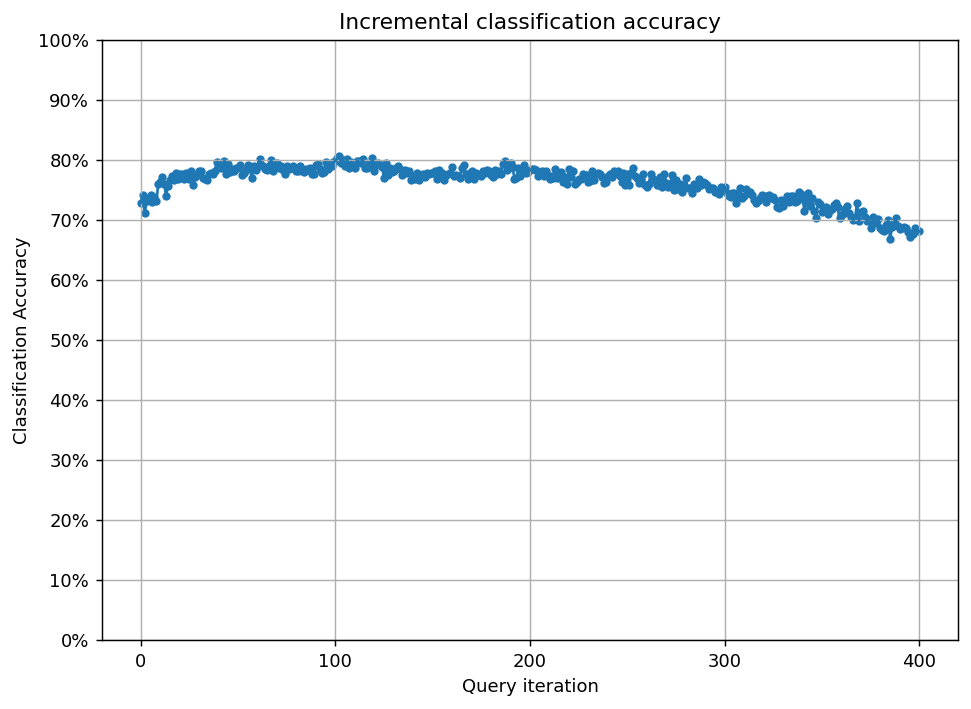

In [12]:
min_len = min(len(s) for s in crw_stories)
crw_stories = [s[:min_len] for s in crw_stories]
med_stories_crw = [np.mean(vals) for vals in zip(*crw_stories)]

# Plot our performance over time.
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories_crw)
ax.scatter(range(len(med_stories_crw)), med_stories_crw, s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')

plt.show()

In [13]:
cyn_stories = []

seeds = [10,20,30,40,50]


for s in seeds:
    np.random.seed(s)

    cyn_anot = np.random.normal(loc=-1,scale=0.5, size=(50,)).tolist()
    
    rate = 0.01
    rate_dif = 0.1
    list_dif = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
    list_dis = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

    X = data.drop(columns = ['risk_label','cluster']).to_numpy()
    Y = data['risk_label'].to_numpy()
    
    X_train, X_pool, Y_train, Y_pool = train_test_split(X, Y,test_size=0.98,random_state=s)
    
    X_pool, X_test, Y_pool, Y_test = train_test_split(X_pool, Y_pool,test_size=0.2,random_state=s)
    
    learner = ActiveLearner(
        estimator=RandomForestClassifier(random_state=s),
        query_strategy=uncertainty_sampling,
        X_training=X_train, y_training=Y_train)
    
    unqueried_score = learner.score(X_test, Y_test)
    
    performance_history = [unqueried_score]

    n_queries = min(400,X_pool.shape[0])
    
    for index in range(n_queries):
    
        uncertainty = learner.predict_proba(X_pool)
        max_uncertainty = np.max(uncertainty, axis=1)
    
        max_uncertainty = np.min(max_uncertainty)
        
        if max_uncertainty > 0.6:
            break
        
        query_index, query_instance = learner.query(X_pool)
    
        # Teach our ActiveLearner model the record it has requested.
        x,y = X_pool[query_index].reshape(1, -1), Y_pool[query_index].reshape(1, )
        y = [rand_imputar(cyn_anot,y[0],query_index[0])[1]]
        learner.teach(X=x, y=y)
    
        # Remove the queried instance from the unlabeled pool.
        X_pool, Y_pool = np.delete(X_pool, query_index, axis=0), np.delete(Y_pool, query_index)
    
        # Calculate and report our model's accuracy.
        model_accuracy = learner.score(X_test, Y_test)
    
        # Save our model's performance for plotting.
        performance_history.append(model_accuracy)

    cyn_stories.append(performance_history)

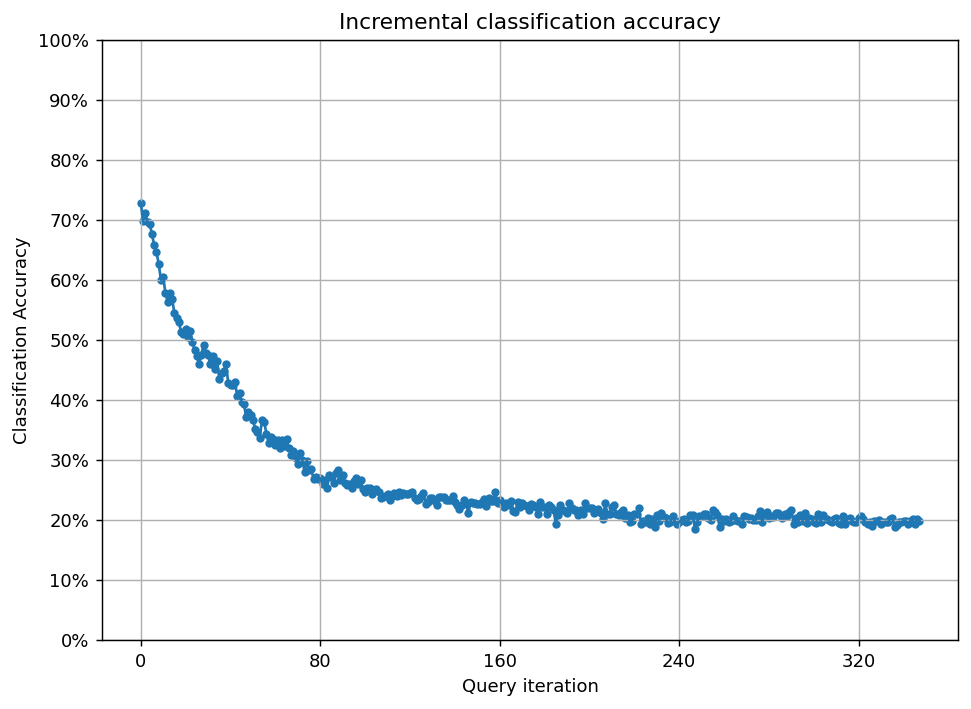

In [14]:
min_len = min(len(s) for s in cyn_stories)
cyn_stories = [s[:min_len] for s in cyn_stories]
med_stories_cyn = [np.mean(vals) for vals in zip(*cyn_stories)]

# Plot our performance over time.
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories_cyn)
ax.scatter(range(len(med_stories_cyn)), med_stories_cyn, s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')

plt.show()

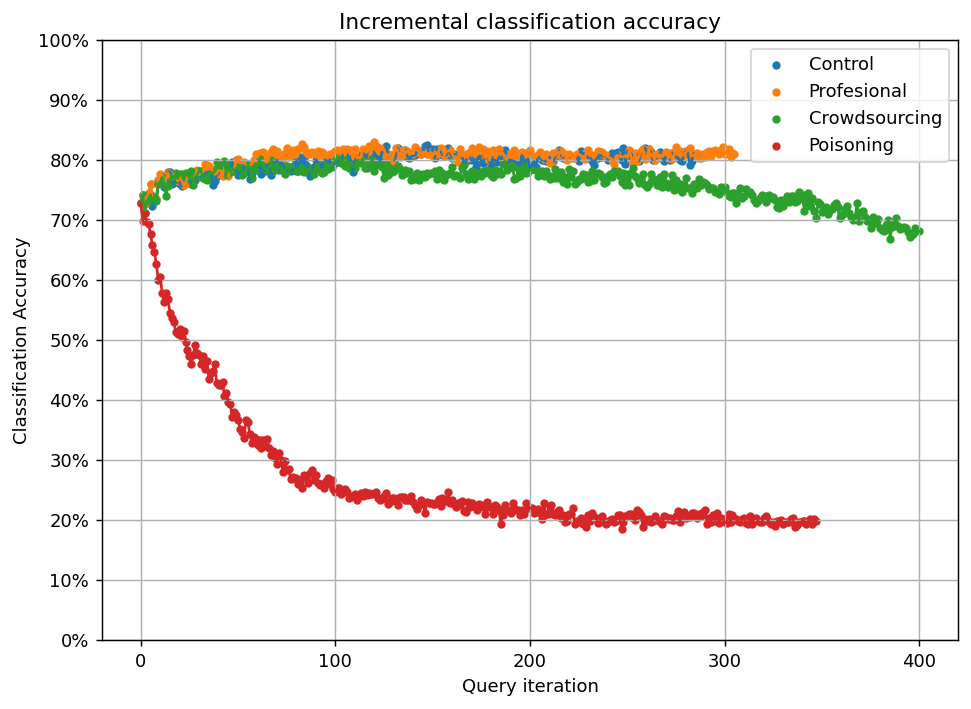

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories_con)
ax.scatter(range(len(med_stories_con)), med_stories_con, label = "Control",s=13)
ax.plot(med_stories_prof)
ax.scatter(range(len(med_stories_prof)), med_stories_prof, label = "Profesional",s=13)
ax.plot(med_stories_crw)
ax.scatter(range(len(med_stories_crw)), med_stories_crw, label = "Crowdsourcing",s=13)
ax.plot(med_stories_cyn)
ax.scatter(range(len(med_stories_cyn)), med_stories_cyn, label = "Poisoning",s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')
ax.legend()

plt.show()